In [16]:
# 1) Imports and configuration
import os
import time
import json
import hashlib
import random
import operator
from functools import reduce
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Dataset and split
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 200
train_frac = 0.8  # keeps n_test_traj=20 when samples_to_load=100

# Reproducibility
seed = 32

# Preprocessing / chunking
sub = 1
chunk_len = 16  # same role as T in train_RNO.ipynb
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True

# Optimization
batch_size = 75
epochs = 100
learning_rate = 1e-3
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5

# RNO model
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

# Ablation controls (Tier-1 for ablation experiment identity)
ablation_seed = int(seed)
baseline_epochs_ablation = 100
multi_step_fine_tuning = True
fine_tuning_num_steps = 5
fine_tune_ep = 25  # use 25 for good results
fine_tuning_lr = 1e-3
fine_tune_scheduler_step = 2000
fine_tune_scheduler_gamma = 0.5

# Rollout eval
rollout_h = 5  # must be >= 5
sample_id = 0
start_chunk = 0


def build_tier1_hparams(ablation_variant, run_seed):
    return {
        "ablation_variant": str(ablation_variant),
        "seed": int(run_seed),
        "data_path": os.path.abspath(data_path),
        "samples_to_load": int(samples_to_load),
        "train_frac": float(train_frac),
        "sub": int(sub),
        "chunk_len": int(chunk_len),
        "n_intervals": int(n_intervals),
        "train_up_to_tipping_point": bool(train_up_to_tipping_point),
        "modes1": int(modes1),
        "modes2": int(modes2),
        "width": int(width),
        "n_layers": int(n_layers),
        "domain_padding": [float(v) for v in domain_padding],
        "learning_rate": float(learning_rate),
        "weight_decay": float(weight_decay),
        "baseline_epochs_ablation": int(baseline_epochs_ablation),
        "fine_tuning_num_steps": int(fine_tuning_num_steps),
        "fine_tune_ep": int(fine_tune_ep),
        "fine_tuning_lr": float(fine_tuning_lr),
    }


def make_scheme_b_experiment_id(ablation_variant, run_seed):
    tier1 = build_tier1_hparams(ablation_variant=ablation_variant, run_seed=run_seed)
    canonical = json.dumps(tier1, sort_keys=True, separators=(",", ":"))
    suffix = hashlib.sha1(canonical.encode("utf-8")).hexdigest()[:10]
    return (
        f"rno_heat_stateonly__variant_{ablation_variant}"
        f"__seed{int(run_seed)}__H{suffix}"
    )


def build_run_dirs(result_root, experiment_id):
    run_dir = os.path.join(result_root, "runs", experiment_id)
    paths = {
        "run_dir": run_dir,
        "checkpoints": os.path.join(run_dir, "checkpoints"),
        "logs": os.path.join(run_dir, "logs"),
        "metrics": os.path.join(run_dir, "metrics"),
    }
    for p in paths.values():
        os.makedirs(p, exist_ok=True)
    return paths


In [2]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")

device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# 3) Data loading (state only)
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
).float()  # (ntraj, nt, nx)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples")
print(f"solutions (raw): {tuple(solutions.shape)}")
print(f"x_cord: {tuple(x_cord.shape)}")
print(f"dt: {dt}")


Loaded 200/3000 samples
solutions (raw): (200, 401, 100)
x_cord: (100, 1)
dt: 0.001


In [4]:
# 4) Helper functions
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nx) -> (ntraj, n_chunks, chunk_size, nx)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)


def build_state_windows(sol_chunks, n_intervals_inner):
    # sol_chunks: (ntraj, n_chunks, chunk_len, nx, 1)
    x_list, y_list = [], []
    for traj in sol_chunks:
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_list.append(traj[i : i + n_intervals_inner])
            y_list.append(traj[i + n_intervals_inner])

    x = torch.stack(x_list, dim=0).float()  # (N, n_intervals, chunk_len, nx, 1)
    y = torch.stack(y_list, dim=0).float()  # (N, chunk_len, nx, 1)
    return x, y


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


In [5]:
# 5) State-only preprocessing: crop, split, chunk
# Spatial subsample on state/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

ntraj, nt_raw, nx = solutions.shape

# Time crop to multiple of chunk_len
nt_usable = round_down(nt_raw, chunk_len)
solutions = solutions[:, :nt_usable, :]

# Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(
        int(tipping_data_split_prop * solutions.shape[1]), chunk_len
    )
    solutions = solutions[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
n_chunks = nt // chunk_len

# Train/test split by trajectory
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]

# Chunk and append channel dim
sol_train_chunks = chunk_time_axis(sol_train, chunk_len).unsqueeze(
    -1
)  # (n_train_traj, n_chunks, chunk_len, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, chunk_len).unsqueeze(
    -1
)  # (n_test_traj, n_chunks, chunk_len, nx, 1)

print("After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"ntraj={ntraj}, nt={nt}, nx={nx}, n_chunks={n_chunks}")
print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
print(f"sol_train_chunks.shape: {tuple(sol_train_chunks.shape)}")
print(f"sol_test_chunks.shape: {tuple(sol_test_chunks.shape)}")


After preprocessing:
solutions: (200, 400, 100)
ntraj=200, nt=400, nx=100, n_chunks=25
n_train_traj=160, n_test_traj=40
sol_train_chunks.shape: (160, 25, 16, 100, 1)
sol_test_chunks.shape: (40, 25, 16, 100, 1)


In [6]:
# 6) Build state-only train/test windows and dataloaders
x_train, y_train = build_state_windows(sol_train_chunks, n_intervals)
x_test, y_test = build_state_windows(sol_test_chunks, n_intervals)

train_loader = DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

test_loader = DataLoader(
    torch.utils.data.TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

print(f"x_train: {tuple(x_train.shape)}")
print(f"y_train: {tuple(y_train.shape)}")
print(f"x_test: {tuple(x_test.shape)}")
print(f"y_test: {tuple(y_test.shape)}")

xb, yb = next(iter(train_loader))
print(f"train batch x: {tuple(xb.shape)}")
print(f"train batch y: {tuple(yb.shape)}")

x_in = xb.permute(0, 1, 4, 2, 3)
print(f"x_in passed to RNO: {tuple(x_in.shape)} (channel dim must be 1)")


x_train: (3040, 5, 16, 100, 1)
y_train: (3040, 16, 100, 1)
x_test: (760, 5, 16, 100, 1)
y_test: (760, 16, 100, 1)
train batch x: (75, 5, 16, 100, 1)
train batch y: (75, 16, 100, 1)
x_in passed to RNO: (75, 5, 1, 16, 100) (channel dim must be 1)


In [7]:
# 7) RNO model, optimizer, scheduler, loss
from neuralop.models import RNO

in_channels = int(x_train.shape[-1])
out_channels = int(y_train.shape[-1])

print(f"Model config -> in_channels={in_channels}, out_channels={out_channels}")
assert in_channels == 1, f"Expected in_channels=1, got {in_channels}"
assert out_channels == 1, f"Expected out_channels=1, got {out_channels}"

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=1,
    out_channels=1,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

print("RNO in_channels/out_channels:", model.in_channels, model.out_channels)
print("Model parameters:", count_params(model))

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


Model config -> in_channels=1, out_channels=1
RNO in_channels/out_channels: 1 1
Model parameters: 3138141


### What Training loop Optimizes
- Cell #8 optimizes only one-step next-chunk prediction (`num_steps=1`) during training.
- The loss is computed between the predicted next chunk and the immediate ground-truth next chunk.
- It does not directly optimize full-trajectory or long-horizon rollout error.
- Multi-step rollout quality is therefore an out-of-distribution consequence of repeated one-step usage.
- To explicitly optimize trajectory-level error, a separate multi-step fine-tuning phase is needed.
- Both endpoint MSE and endpoint relative L2 are reported below per horizon. (MSE is scale-dependent, while relative L2 is scale-normalized by target magnitude.)




In [8]:
# 8) Training loop (state-only)
import torch.nn.functional as F

num_train_samples = x_train.shape[0]
num_test_samples = x_test.shape[0]
training_loss_history = []
test_loss_history = []

# Root directory stays stable; run-specific outputs use Scheme-B experiment IDs.
result_dir = f"result_rno_state_only_{seed}"
os.makedirs(result_dir, exist_ok=True)

main_variant = "main_training"
main_experiment_id = make_scheme_b_experiment_id(main_variant, seed)
main_run_dirs = build_run_dirs(result_dir, main_experiment_id)

log_file = os.path.join(main_run_dirs["logs"], "train_log.csv")
with open(log_file, "w") as f:
    f.write("epoch,loss_train_mse,loss_test_l2,runtime\n")


In [9]:
debug_shapes_printed = False
print("Begin RNO training (state-only):")
for ep in range(1, epochs + 1):
    t_start = time.time()
    model.train()
    train_mse = 0.0
    for x_batch, y_batch in tqdm(train_loader, leave=False):
        x_batch = x_batch.to(device).float()  # (B, n_intervals, chunk_len, nx, 1)
        y_batch = y_batch.to(device).float()  # (B, chunk_len, nx, 1)
        x_in = x_batch.permute(0, 1, 4, 2, 3)  # (B, n_intervals, 1, chunk_len, nx)
        out = model.predict(x_in, num_steps=1)[:, -1]  # (B, 1, chunk_len, nx)
        out = out.permute(0, 2, 3, 1)  # (B, chunk_len, nx, 1)
        if not debug_shapes_printed:
            print("pred_rollout shape:", model.predict(x_in, num_steps=1).shape)
            print("pred_rollout[:, -1] shape:", out.shape)
            print("yb shape:", y_batch.shape)
            debug_shapes_printed = True
        loss = F.mse_loss(out, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_mse += loss.item() * x_batch.size(0)
    model.eval()
    test_l2_metric = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float()
            x_in = x_batch.permute(0, 1, 4, 2, 3)
            out = model.predict(x_in, num_steps=1)[:, -1]
            out = out.permute(0, 2, 3, 1)
            test_l2_metric += lploss(out, y_batch).item() * x_batch.size(0)
    train_mse /= num_train_samples
    test_l2_metric /= num_test_samples
    training_loss_history.append(train_mse)
    test_loss_history.append(test_l2_metric)
    runtime = time.time() - t_start
    print(
        f"Epoch {ep:03d}/{epochs} | train_mse={train_mse:.4e} | test_l2={test_l2_metric:.4e} | runtime={runtime:.2f}s"
    )
    with open(log_file, "a") as f:
        f.write(f"{ep},{train_mse},{test_l2_metric},{runtime}\n")


Begin RNO training (state-only):


  0%|          | 0/20 [00:00<?, ?it/s]

pred_rollout shape: torch.Size([75, 1, 1, 16, 100])
pred_rollout[:, -1] shape: torch.Size([75, 16, 100, 1])
yb shape: torch.Size([75, 16, 100, 1])
Epoch 001/5 | train_mse=2.0348e+00 | test_l2=7.4164e+01 | runtime=5.77s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 002/5 | train_mse=2.0218e+00 | test_l2=7.4100e+01 | runtime=4.65s


...

Epoch 003/5 | train_mse=2.0285e+00 | test_l2=7.3911e+01 | runtime=4.62s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 004/5 | train_mse=2.0196e+00 | test_l2=7.3897e+01 | runtime=4.70s


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 005/5 | train_mse=2.0147e+00 | test_l2=7.3769e+01 | runtime=4.67s


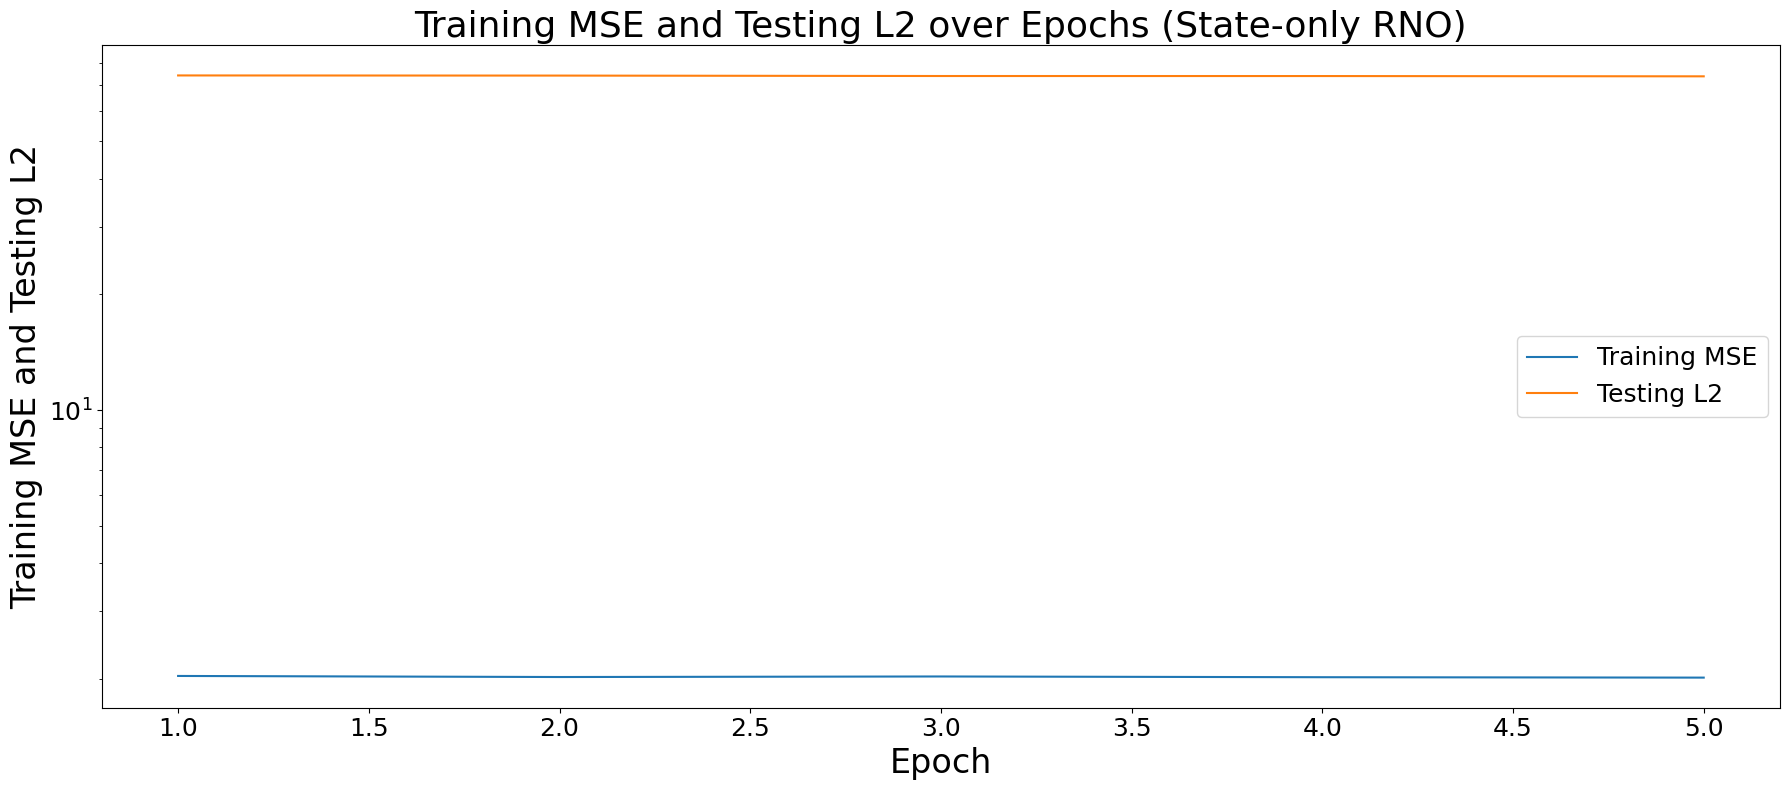

Plots saved to result_rno_state_only_32/train_and_test_loss_plots.png


In [10]:
# 9) Plot training progress (same style family as original notebooks)
df = pd.read_csv(log_file)
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 8), dpi=100)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

ax1.plot(
    df["epoch"],
    df["loss_train_mse"],
    label="Training MSE",
    color=colors[0],
    linestyle="-",
)
ax1.plot(
    df["epoch"],
    df["loss_test_l2"],
    label="Testing L2",
    color=colors[1],
    linestyle="-",
)
ax1.set_yscale("log")
ax1.set_xlabel("Epoch", fontsize=24)
ax1.set_ylabel("Training MSE and Testing L2", fontsize=24)
ax1.set_title("Training MSE and Testing L2 over Epochs (State-only RNO)", fontsize=26)
ax1.legend(loc="best", fontsize=18)
ax1.tick_params(axis="both", which="major", labelsize=18)

plt.tight_layout()
plot_path = os.path.join(result_dir, "train_and_test_loss_plots.png")
plt.savefig(plot_path, dpi=100)
plt.show()
plt.close(fig)
print(f"Plots saved to {plot_path}")


In [11]:
# 10) Save model checkpoint
main_tier1_hparams = build_tier1_hparams(main_variant, seed)

checkpoint_payload_main = {
    "schema_version": "rno_heat_state_only.v2",
    "experiment_id": main_experiment_id,
    "ablation_variant": main_variant,
    "tier1_hparams": main_tier1_hparams,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_state_dict": model.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "seed": seed,
    "epochs": epochs,
    "config": {
        "modes1": modes1,
        "modes2": modes2,
        "width": width,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
        "in_channels": 1,
        "out_channels": 1,
        "chunk_len": chunk_len,
        "n_intervals": n_intervals,
        "sub": sub,
        "train_frac": train_frac,
    },
    "hparams": {
        "data": {
            "data_path": data_path,
            "samples_to_load": samples_to_load,
            "train_frac": train_frac,
            "sub": sub,
            "chunk_len": chunk_len,
            "n_intervals": n_intervals,
            "train_up_to_tipping_point": train_up_to_tipping_point,
            "tipping_data_split_prop": tipping_data_split_prop,
        },
        "model": {
            "modes1": modes1,
            "modes2": modes2,
            "width": width,
            "n_layers": n_layers,
            "domain_padding": domain_padding,
            "in_channels": 1,
            "out_channels": 1,
        },
        "training": {
            "baseline": {
                "batch_size": batch_size,
                "epochs": epochs,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
            },
            "finetune": {
                "baseline_epochs_ablation": baseline_epochs_ablation,
                "fine_tuning_num_steps": fine_tuning_num_steps,
                "fine_tune_ep": fine_tune_ep,
                "fine_tuning_lr": fine_tuning_lr,
                "fine_tune_scheduler_step": fine_tune_scheduler_step,
                "fine_tune_scheduler_gamma": fine_tune_scheduler_gamma,
            },
        },
        "evaluation": {
            "rollout_h": rollout_h,
            "sample_id": sample_id,
            "start_chunk": start_chunk,
        },
        "reproducibility": {
            "seed": seed,
            "cudnn_deterministic": bool(torch.backends.cudnn.deterministic),
            "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
        },
    },
    "train_loss_history": training_loss_history,
    "test_loss_history": test_loss_history,
}

model_path = os.path.join(main_run_dirs["checkpoints"], "checkpoint_main_training.pt")
torch.save(checkpoint_payload_main, model_path)
print(f"Saved checkpoint to {model_path}")

# Backward-compatible legacy location for existing evaluation scripts.
legacy_model_path = os.path.join(result_dir, "rno_state_only_last.pt")
torch.save(checkpoint_payload_main, legacy_model_path)
print(f"Saved legacy checkpoint to {legacy_model_path}")


Saved checkpoint to result_rno_state_only_32/runs/rno_heat_stateonly__variant_main_training__seed32__H3157b2cfce/checkpoints/checkpoint_main_training.pt
Saved legacy checkpoint to result_rno_state_only_32/rno_state_only_last.pt


## 11) Three-Way Ablation (Shared Setup)
This section builds shared multi-horizon datasets/loaders and reusable train/eval functions.
All three models use the same architecture, data split, batch size, and endpoint-only evaluation windows.


In [9]:
# 11a) Shared setup for ablation fairness
import torch.nn.functional as F
from neuralop.models import RNO

# Reproducibility root
random.seed(ablation_seed)
np.random.seed(ablation_seed)
torch.manual_seed(ablation_seed)

# Legacy + new output directories
ablation_result_dir = os.path.join(result_dir, "ablation_three_way")
os.makedirs(ablation_result_dir, exist_ok=True)

ablation_variants = [
    "baseline_only",
    "finetune_only",
    "baseline_plus_finetune",
]
ablation_experiment_ids = {
    variant: make_scheme_b_experiment_id(variant, ablation_seed)
    for variant in ablation_variants
}
ablation_run_dirs = {
    variant: build_run_dirs(result_dir, ablation_experiment_ids[variant])
    for variant in ablation_variants
}

# Use same loss family as existing notebook
lploss_eval = LpLoss(size_average=False)

print("Ablation setup:")
print(f"seed={ablation_seed}")
print(f"baseline_epochs={baseline_epochs_ablation}")
print(f"fine_tuning_num_steps={fine_tuning_num_steps}, fine_tune_ep={fine_tune_ep}")
print(f"batch_size={batch_size}, chunk_len={chunk_len}, n_intervals={n_intervals}")
print(f"train split windows={x_train.shape[0]}, test split windows={x_test.shape[0]}")
print(
    f"sol_train_chunks={tuple(sol_train_chunks.shape)}, sol_test_chunks={tuple(sol_test_chunks.shape)}"
)
print("Ablation run IDs:")
for variant in ablation_variants:
    print(f"  {variant}: {ablation_experiment_ids[variant]}")


Ablation setup:
seed=32
baseline_epochs=5
fine_tuning_num_steps=5, fine_tune_ep=25
batch_size=75, chunk_len=16, n_intervals=5
train split windows=3040, test split windows=760
sol_train_chunks=(160, 25, 16, 100, 1), sol_test_chunks=(40, 25, 16, 100, 1)
Ablation run IDs:
  baseline_only: rno_heat_stateonly__variant_baseline_only__seed32__Hddb809c98d
  finetune_only: rno_heat_stateonly__variant_finetune_only__seed32__H158fa38e5e
  baseline_plus_finetune: rno_heat_stateonly__variant_baseline_plus_finetune__seed32__H2b54b40d3d


In [10]:
# 11b) Build shared multi-horizon datasets and deterministic test loaders


def build_state_windows_horizon(sol_chunks, n_intervals_inner, horizon_inner):
    x_list, y_list = [], []
    for traj in sol_chunks:
        max_i = sol_chunks.shape[1] - n_intervals_inner - horizon_inner
        for i in range(max_i):
            x_list.append(traj[i : i + n_intervals_inner])
            y_list.append(traj[i + n_intervals_inner + horizon_inner - 1])

    if len(x_list) == 0:
        # Keep shape-consistent empty tensors
        x_empty = torch.empty(0, n_intervals_inner, chunk_len, nx, 1)
        y_empty = torch.empty(0, chunk_len, nx, 1)
        return x_empty.float(), y_empty.float()

    x = torch.stack(x_list, dim=0).float()  # (N, n_intervals, chunk_len, nx, 1)
    y = torch.stack(y_list, dim=0).float()  # (N, chunk_len, nx, 1)
    return x, y


horizons = list(range(1, fine_tuning_num_steps + 1))

multi_step_train_data = {}
multi_step_test_data = {}
for h in horizons:
    xh_tr, yh_tr = build_state_windows_horizon(sol_train_chunks, n_intervals, h)
    xh_te, yh_te = build_state_windows_horizon(sol_test_chunks, n_intervals, h)
    multi_step_train_data[h] = (xh_tr, yh_tr)
    multi_step_test_data[h] = (xh_te, yh_te)

# Shared deterministic evaluation loaders (identical windows for all models)
multi_step_test_eval_loaders = {}
for h in horizons:
    xh_te, yh_te = multi_step_test_data[h]
    multi_step_test_eval_loaders[h] = DataLoader(
        torch.utils.data.TensorDataset(xh_te, yh_te),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

n_eval_per_horizon = {h: multi_step_test_data[h][0].shape[0] for h in horizons}
print("Evaluation samples per horizon:", n_eval_per_horizon)


Evaluation samples per horizon: {1: 760, 2: 720, 3: 680, 4: 640, 5: 600}


### 11c note: baseline vs multi-step supervision

- `run_one_step_baseline_training` always uses `num_steps=1`, so each batch trains on the next single target window (`h=1`).
- `run_multistep_finetuning` uses horizons `h=1..fine_tuning_num_steps` (here `1..5`). For each epoch, it trains on **all** horizons, but in shuffled order.
- In multi-step mode, `pred_rollout = model.predict(..., num_steps=h)` has shape `(B, h, C, T, n_x)`. The code uses `pred_rollout[:, -1]`, which is the final predicted window at that horizon.
- So if you see `pred_rollout.shape = [75, 3, 1, 16, 100]`, that batch came from horizon `h=3`. This does not mean the run is limited to 3; other batches in the same epoch use `h=1,2,4,5` as well.


In [11]:
# 11c) Shared model/train/eval helpers
def build_model_with_seed(init_seed):
    torch.manual_seed(init_seed)
    np.random.seed(init_seed)
    random.seed(init_seed)
    return RNO(
        n_modes=(modes1, modes2),
        hidden_channels=width,
        in_channels=1,
        out_channels=1,
        n_layers=n_layers,
        domain_padding=domain_padding,
    ).to(device)


# Trajectory-vs-endpoint confirmation (current notebook vs ks/RNO_KS.py):
# - Current baseline supervision is trajectory-window loss (not endpoint-only state loss).
# - pred_rollout dimensions are interpreted as (B, rollout_window_index, dim, T, n_x).
# - Therefore pred_rollout[:, -1] is shape (B, dim, T, n_x): it is a full trajectory window,
#   not a single endpoint state (which would be (B, dim, n_x) or (B, n_x, dim)).
# - yb is shape (B, T, n_x, dim), so yb is also a full trajectory window target.
# - This matches ks/RNO_KS.py baseline semantics: loss compares full window tensors via
#   loss = lploss(out, y), where out is permuted to (B, T, n_x, dim).
def run_one_step_baseline_training(
    model_obj, train_x, train_y, test_x, test_y, n_epochs, seed_for_loader
):
    # Deterministic train shuffle order for fairness.
    g = torch.Generator(device="cpu")
    g.manual_seed(seed_for_loader)
    train_loader_local = DataLoader(
        torch.utils.data.TensorDataset(train_x, train_y),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=g,
    )
    test_loader_local = DataLoader(
        torch.utils.data.TensorDataset(test_x, test_y),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )
    optimizer_local = torch.optim.Adam(
        model_obj.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    scheduler_local = torch.optim.lr_scheduler.StepLR(
        optimizer_local, step_size=scheduler_step, gamma=scheduler_gamma
    )
    history = {"train_rel_l2": [], "test_rel_l2": []}
    debug_shapes_printed = False
    for ep in range(1, n_epochs + 1):
        t_start = time.time()
        model_obj.train()
        train_l2_sum = 0.0
        train_count = 0
        for xb, yb in train_loader_local:
            xb = xb.to(device).float()
            yb = yb.to(device).float()
            x_in = xb.permute(0, 1, 4, 2, 3)
            pred_rollout = model_obj.predict(x_in, num_steps=1)
            out_window = pred_rollout[:, -1].permute(0, 2, 3, 1)
            if not debug_shapes_printed:
                print("pred_rollout shape:", pred_rollout.shape)
                print("pred_rollout[:, -1] shape:", pred_rollout[:, -1].shape)
                print("yb shape:", yb.shape)
                debug_shapes_printed = True
            loss = lploss(out_window, yb)
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
            scheduler_local.step()
            train_l2_sum += loss.item()
            train_count += xb.size(0)
        model_obj.eval()
        test_rel_sum = 0.0
        test_count = 0
        with torch.no_grad():
            for xb, yb in test_loader_local:
                xb = xb.to(device).float()
                yb = yb.to(device).float()
                x_in = xb.permute(0, 1, 4, 2, 3)
                pred_rollout = model_obj.predict(x_in, num_steps=1)
                out_window = pred_rollout[:, -1].permute(0, 2, 3, 1)
                test_rel_sum += lploss(out_window, yb).item()
                test_count += xb.size(0)
        train_l2 = train_l2_sum / max(train_count, 1)
        test_l2 = test_rel_sum / max(test_count, 1)
        history["train_rel_l2"].append(train_l2)
        history["test_rel_l2"].append(test_l2)
        runtime = time.time() - t_start
        print(
            f"Epoch {ep:03d}/{n_epochs} | Train L2={train_l2:.4e} | Test L2={test_l2:.4e} | runtime={runtime:.2f}s"
        )
    return history


# Trajectory-vs-endpoint confirmation (current notebook vs ks/RNO_KS.py):
# - Current multi-step fine-tuning supervision is trajectory-window loss (not endpoint-only state loss).
# - pred_rollout dimensions are interpreted as (B, rollout_window_index, dim, T, n_x).
# - pred_rollout[:, -1] has shape (B, dim, T, n_x), so it still contains T time slices.
# - yb has shape (B, T, n_x, dim), i.e., full trajectory window targets.
# - Loss compares out_window and yb directly (LpLoss internally flattens per sample),
#   so no external n_x/T/dim reshape variables are required.
# - ks/RNO_KS.py uses the same `[:, -1]` window-index selection plus full-window flattening,
#   so the two implementations are semantically equivalent.
def run_multistep_finetuning(model_obj, train_data_by_h, test_data_by_h, ft_seed):
    # Build deterministic train loaders per horizon.
    train_loaders = {}
    test_loaders = {}
    for h in horizons:
        xh_tr, yh_tr = train_data_by_h[h]
        xh_te, yh_te = test_data_by_h[h]
        g_h = torch.Generator(device="cpu")
        g_h.manual_seed(ft_seed)
        train_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(xh_tr, yh_tr),
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            generator=g_h,
        )
        test_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(xh_te, yh_te),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

    # KS-style mixed horizon list: one entry per batch in each horizon loader.
    multi_step_list_template = []
    for h in horizons:
        multi_step_list_template += [h for _ in range(len(train_loaders[h]))]

    optimizer_ft = torch.optim.Adam(
        model_obj.parameters(), lr=fine_tuning_lr, weight_decay=weight_decay
    )
    scheduler_ft = torch.optim.lr_scheduler.StepLR(
        optimizer_ft,
        step_size=fine_tune_scheduler_step,
        gamma=fine_tune_scheduler_gamma,
    )

    ft_logs = {
        "train_rel_l2": {h: [] for h in horizons},
        "test_rel_l2": {h: [] for h in horizons},
    }

    print("Begin multi-step fine-tuning:")
    rng_ft = random.Random(ft_seed)
    debug_shapes_printed = False

    for ep in range(1, fine_tune_ep + 1):
        t_start = time.time()

        multi_step_list = multi_step_list_template.copy()
        rng_ft.shuffle(multi_step_list)
        iters = {h: iter(train_loaders[h]) for h in horizons}

        model_obj.train()
        train_l2_sum = {h: 0.0 for h in horizons}
        train_count = {h: 0 for h in horizons}

        for h in tqdm(multi_step_list, total=len(multi_step_list)):
            xb, yb = next(iters[h])
            xb = xb.to(device).float()
            yb = yb.to(device).float()

            x_in = xb.permute(0, 1, 4, 2, 3)
            pred_rollout = model_obj.predict(x_in, num_steps=h)
            out_window = pred_rollout[:, -1].permute(0, 2, 3, 1)
            if not debug_shapes_printed:
                print("pred_rollout shape:", pred_rollout.shape)
                print("pred_rollout[:, -1] shape:", pred_rollout[:, -1].shape)
                print("yb shape:", yb.shape)
                debug_shapes_printed = True

            l2 = lploss(out_window, yb)

            optimizer_ft.zero_grad()
            l2.backward()
            optimizer_ft.step()
            scheduler_ft.step()

            train_l2_sum[h] += l2.item()
            train_count[h] += xb.size(0)

        model_obj.eval()
        test_rel_sum = {h: 0.0 for h in horizons}
        test_count = {h: 0 for h in horizons}
        with torch.no_grad():
            for h in horizons:
                for xb, yb in test_loaders[h]:
                    xb = xb.to(device).float()
                    yb = yb.to(device).float()
                    x_in = xb.permute(0, 1, 4, 2, 3)
                    pred_rollout = model_obj.predict(x_in, num_steps=h)
                    out_window = pred_rollout[:, -1].permute(0, 2, 3, 1)
                    test_rel_sum[h] += lploss(out_window, yb).item()
                    test_count[h] += xb.size(0)

        train_l2_list = []
        test_l2_list = []
        for h in horizons:
            train_l2_h = train_l2_sum[h] / max(train_count[h], 1)
            test_l2_h = test_rel_sum[h] / max(test_count[h], 1)

            ft_logs["train_rel_l2"][h].append(train_l2_h)
            ft_logs["test_rel_l2"][h].append(test_l2_h)

            train_l2_list.append(train_l2_h)
            test_l2_list.append(test_l2_h)

        runtime = time.time() - t_start
        print(
            f"Fine-tune epoch: {ep} Time: {runtime:.2f} Train L2: {train_l2_list} Test L2: {test_l2_list}"
        )

    return ft_logs


def evaluate_endpoint_metrics(model_obj, eval_loaders_by_h):
    model_obj.eval()
    results = {}
    with torch.no_grad():
        for h in horizons:
            loader = eval_loaders_by_h[h]
            mse_sum = 0.0
            rel_sum = 0.0
            n_total = 0
            for xb, yb in loader:
                xb = xb.to(device).float()
                yb = yb.to(device).float()
                x_in = xb.permute(0, 1, 4, 2, 3)
                out = model_obj.predict(x_in, num_steps=h)[:, -1]
                out = out.permute(0, 2, 3, 1)
                # Per-window endpoint MSE
                mse_per = torch.mean((out - yb) ** 2, dim=(1, 2, 3))
                # Per-window endpoint relative L2 on flattened chunk
                diff_flat = (out - yb).reshape(out.shape[0], -1)
                y_flat = yb.reshape(yb.shape[0], -1)
                rel_per = torch.linalg.norm(diff_flat, dim=1) / (
                    torch.linalg.norm(y_flat, dim=1) + 1e-12
                )
                mse_sum += mse_per.sum().item()
                rel_sum += rel_per.sum().item()
                n_total += xb.size(0)
            results[h] = {
                "mse": mse_sum / max(n_total, 1),
                "rel_l2": rel_sum / max(n_total, 1),
                "N": int(n_total),
            }
    return results


## 12) Baseline-only (25 epochs one-step)
Model A: baseline training only, then multi-horizon endpoint evaluation.


In [17]:
# 12) Baseline-only run
variant_A = "baseline_only"
model_A = build_model_with_seed(ablation_seed)
history_A = run_one_step_baseline_training(
    model_obj=model_A,
    train_x=x_train,
    train_y=y_train,
    test_x=x_test,
    test_y=y_test,
    n_epochs=baseline_epochs_ablation,
    seed_for_loader=ablation_seed,
)
results_baseline = evaluate_endpoint_metrics(model_A, multi_step_test_eval_loaders)
ckpt_A = {
    "schema_version": "rno_heat_state_only.v2",
    "experiment_id": ablation_experiment_ids[variant_A],
    "ablation_variant": variant_A,
    "tag": variant_A,  # backward compatibility alias
    "tier1_hparams": build_tier1_hparams(variant_A, ablation_seed),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_state_dict": model_A.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "seed": ablation_seed,
    "hparams": {
        "training": {
            "baseline": {
                "epochs": baseline_epochs_ablation,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
                "batch_size": batch_size,
            },
            "finetune": {
                "fine_tuning_num_steps": fine_tuning_num_steps,
                "fine_tune_ep": fine_tune_ep,
                "fine_tuning_lr": fine_tuning_lr,
                "fine_tune_scheduler_step": fine_tune_scheduler_step,
                "fine_tune_scheduler_gamma": fine_tune_scheduler_gamma,
            },
        },
        "evaluation": {
            "eval_steps": fine_tuning_num_steps,
            "endpoint_only": True,
            "metrics": ["mse", "rel_l2"],
            "rollout_h": rollout_h,
            "sample_id": sample_id,
            "start_chunk": start_chunk,
        },
        "reproducibility": {
            "seed": seed,
            "cudnn_deterministic": bool(torch.backends.cudnn.deterministic),
            "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
        },
    },
    "metrics": {
        "endpoint_by_horizon": results_baseline,
        "baseline_history": history_A,
        "finetune_history": None,
    },
}

ckpt_A_path = os.path.join(
    ablation_run_dirs[variant_A]["checkpoints"], f"checkpoint_{variant_A}.pt"
)
torch.save(ckpt_A, ckpt_A_path)
print("Saved:", ckpt_A_path)

# Backward-compatible legacy location
legacy_ckpt_A = os.path.join(ablation_result_dir, "baseline_only_state_dict.pt")
torch.save(ckpt_A, legacy_ckpt_A)
print("Saved legacy:", legacy_ckpt_A)


pred_rollout shape: torch.Size([75, 1, 1, 16, 100])
pred_rollout[:, -1] shape: torch.Size([75, 1, 16, 100])
yb shape: torch.Size([75, 16, 100, 1])
Epoch 001/100 | Train L2=1.0886e+00 | Test L2=7.4507e-01 | runtime=9.60s
Epoch 002/100 | Train L2=7.6760e-01 | Test L2=7.1170e-01 | runtime=9.47s
Epoch 003/100 | Train L2=7.3430e-01 | Test L2=6.9190e-01 | runtime=9.49s
Epoch 004/100 | Train L2=7.0577e-01 | Test L2=6.6506e-01 | runtime=9.50s
Epoch 005/100 | Train L2=6.8248e-01 | Test L2=6.4687e-01 | runtime=9.51s
Epoch 006/100 | Train L2=6.6525e-01 | Test L2=6.3496e-01 | runtime=9.55s
Epoch 007/100 | Train L2=6.5159e-01 | Test L2=6.2911e-01 | runtime=9.53s
Epoch 008/100 | Train L2=6.4699e-01 | Test L2=6.2446e-01 | runtime=9.55s
Epoch 009/100 | Train L2=6.4200e-01 | Test L2=6.2045e-01 | runtime=9.51s
Epoch 010/100 | Train L2=6.3988e-01 | Test L2=6.1936e-01 | runtime=9.70s
Epoch 011/100 | Train L2=6.3713e-01 | Test L2=6.1833e-01 | runtime=9.79s
Epoch 012/100 | Train L2=6.3603e-01 | Test L2=6.17

## 13) Fine-tune-only (KS-style, from random initialization)
Model B: no baseline training; multi-step fine-tuning only.


In [12]:
# 13) Fine-tune-only run
variant_B = "finetune_only"
model_B = build_model_with_seed(ablation_seed)
logs_B = run_multistep_finetuning(
    model_obj=model_B,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=ablation_seed,
)
results_finetune_only = evaluate_endpoint_metrics(model_B, multi_step_test_eval_loaders)
ckpt_B = {
    "schema_version": "rno_heat_state_only.v2",
    "experiment_id": ablation_experiment_ids[variant_B],
    "ablation_variant": variant_B,
    "tag": variant_B,  # backward compatibility alias
    "tier1_hparams": build_tier1_hparams(variant_B, ablation_seed),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_state_dict": model_B.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "seed": ablation_seed,
    "hparams": {
        "training": {
            "baseline": {
                "epochs": baseline_epochs_ablation,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
                "batch_size": batch_size,
            },
            "finetune": {
                "fine_tuning_num_steps": fine_tuning_num_steps,
                "fine_tune_ep": fine_tune_ep,
                "fine_tuning_lr": fine_tuning_lr,
                "fine_tune_scheduler_step": fine_tune_scheduler_step,
                "fine_tune_scheduler_gamma": fine_tune_scheduler_gamma,
            },
        },
        "evaluation": {
            "eval_steps": fine_tuning_num_steps,
            "endpoint_only": True,
            "metrics": ["mse", "rel_l2"],
            "rollout_h": rollout_h,
            "sample_id": sample_id,
            "start_chunk": start_chunk,
        },
        "reproducibility": {
            "seed": seed,
            "cudnn_deterministic": bool(torch.backends.cudnn.deterministic),
            "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
        },
    },
    "metrics": {
        "endpoint_by_horizon": results_finetune_only,
        "baseline_history": None,
        "finetune_history": logs_B,
    },
}

ckpt_B_path = os.path.join(
    ablation_run_dirs[variant_B]["checkpoints"], f"checkpoint_{variant_B}.pt"
)
torch.save(ckpt_B, ckpt_B_path)
print("Saved:", ckpt_B_path)

# Backward-compatible legacy location
legacy_ckpt_B = os.path.join(ablation_result_dir, "finetune_only_state_dict.pt")
torch.save(ckpt_B, legacy_ckpt_B)
print("Saved legacy:", legacy_ckpt_B)


Begin multi-step fine-tuning:


  0%|          | 0/180 [00:00<?, ?it/s]

pred_rollout shape: torch.Size([75, 1, 1, 16, 100])
pred_rollout[:, -1] shape: torch.Size([75, 1, 16, 100])
yb shape: torch.Size([75, 16, 100, 1])
Fine-tune epoch: 1 Time: 59.44 Train L2: [1.0659073270161947, 0.932275355824253, 0.9449322820592809, 1.415856683768478, 1.589088576634725] Test L2: [0.7569774019090753, 0.7966023445129394, 0.8468987107276916, 0.8795382082462311, 0.9023489316304525]


  0%|          | 0/180 [00:00<?, ?it/s]

Fine-tune epoch: 2 Time: 57.73 Train L2: [0.7694800936381022, 0.8050194723564282, 0.8333741746125398, 0.8741211206772748, 0.9128581523895264] Test L2: [0.7031067848205567, 0.760797627766927, 0.8082085655016058, 0.8324793338775635, 0.8539936002095541]


...

Fine-tune epoch: 23 Time: 58.63 Train L2: [0.07276868438720703, 0.08583104652270936, 0.11996471034155952, 0.17762685065175973, 0.26353341897328697] Test L2: [0.07199667637285433, 0.10021152363883125, 0.1831735324333696, 0.30727421045303344, 0.4546171506245931]


  0%|          | 0/180 [00:00<?, ?it/s]

Fine-tune epoch: 24 Time: 59.24 Train L2: [0.06834528430302937, 0.08237934514095908, 0.11218841658698188, 0.16589261260687135, 0.2518746455510457] Test L2: [0.06819987626452195, 0.09996103445688884, 0.18508496126707863, 0.3156528785824776, 0.46692020416259766]


  0%|          | 0/180 [00:00<?, ?it/s]

Fine-tune epoch: 25 Time: 58.54 Train L2: [0.07041449038187662, 0.08597102918122944, 0.11801260453683358, 0.1753710294237324, 0.2733446995417277] Test L2: [0.08663993320967021, 0.11811950339211358, 0.19576901784714532, 0.32954845726490023, 0.4925962829589844]
Saved: result_rno_state_only_32/runs/rno_heat_stateonly__variant_finetune_only__seed32__H158fa38e5e/checkpoints/checkpoint_finetune_only.pt
Saved legacy: result_rno_state_only_32/ablation_three_way/finetune_only_state_dict.pt


## 14) Baseline → Fine-tune
Model C: 25-epoch baseline, then the same multi-step fine-tuning stage.


In [13]:
# 14) Baseline + fine-tune run
variant_C = "baseline_plus_finetune"
model_C = build_model_with_seed(ablation_seed)
history_C_baseline = run_one_step_baseline_training(
    model_obj=model_C,
    train_x=x_train,
    train_y=y_train,
    test_x=x_test,
    test_y=y_test,
    n_epochs=baseline_epochs_ablation,
    seed_for_loader=ablation_seed,  # same seed everywhere
)
logs_C_ft = run_multistep_finetuning(
    model_obj=model_C,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=ablation_seed,  # same seed everywhere
)
results_baseline_plus_finetune = evaluate_endpoint_metrics(
    model_C, multi_step_test_eval_loaders
)
ckpt_C = {
    "schema_version": "rno_heat_state_only.v2",
    "experiment_id": ablation_experiment_ids[variant_C],
    "ablation_variant": variant_C,
    "tag": variant_C,  # backward compatibility alias
    "tier1_hparams": build_tier1_hparams(variant_C, ablation_seed),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_state_dict": model_C.state_dict(),
    "model_kwargs": {
        "n_modes": (modes1, modes2),
        "hidden_channels": width,
        "in_channels": 1,
        "out_channels": 1,
        "n_layers": n_layers,
        "domain_padding": domain_padding,
    },
    "seed": ablation_seed,
    "hparams": {
        "training": {
            "baseline": {
                "epochs": baseline_epochs_ablation,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
                "batch_size": batch_size,
            },
            "finetune": {
                "fine_tuning_num_steps": fine_tuning_num_steps,
                "fine_tune_ep": fine_tune_ep,
                "fine_tuning_lr": fine_tuning_lr,
                "fine_tune_scheduler_step": fine_tune_scheduler_step,
                "fine_tune_scheduler_gamma": fine_tune_scheduler_gamma,
            },
        },
        "evaluation": {
            "eval_steps": fine_tuning_num_steps,
            "endpoint_only": True,
            "metrics": ["mse", "rel_l2"],
            "rollout_h": rollout_h,
            "sample_id": sample_id,
            "start_chunk": start_chunk,
        },
        "reproducibility": {
            "seed": seed,
            "cudnn_deterministic": bool(torch.backends.cudnn.deterministic),
            "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
        },
    },
    "metrics": {
        "endpoint_by_horizon": results_baseline_plus_finetune,
        "baseline_history": history_C_baseline,
        "finetune_history": logs_C_ft,
    },
}

ckpt_C_path = os.path.join(
    ablation_run_dirs[variant_C]["checkpoints"], f"checkpoint_{variant_C}.pt"
)
torch.save(ckpt_C, ckpt_C_path)
print("Saved:", ckpt_C_path)

# Backward-compatible legacy location
legacy_ckpt_C = os.path.join(
    ablation_result_dir, "baseline_plus_finetune_state_dict.pt"
)
torch.save(ckpt_C, legacy_ckpt_C)
print("Saved legacy:", legacy_ckpt_C)


pred_rollout shape: torch.Size([75, 1, 1, 16, 100])
pred_rollout[:, -1] shape: torch.Size([75, 1, 16, 100])
yb shape: torch.Size([75, 16, 100, 1])
Epoch 001/5 | Train L2=1.0886e+00 | Test L2=7.4507e-01 | runtime=9.69s
Epoch 002/5 | Train L2=7.6760e-01 | Test L2=7.1170e-01 | runtime=10.20s
Epoch 003/5 | Train L2=7.3430e-01 | Test L2=6.9190e-01 | runtime=9.78s
Epoch 004/5 | Train L2=7.0577e-01 | Test L2=6.6506e-01 | runtime=9.68s
Epoch 005/5 | Train L2=6.8248e-01 | Test L2=6.4687e-01 | runtime=9.64s
Begin multi-step fine-tuning:


  0%|          | 0/180 [00:00<?, ?it/s]

pred_rollout shape: torch.Size([75, 1, 1, 16, 100])
pred_rollout[:, -1] shape: torch.Size([75, 1, 16, 100])
yb shape: torch.Size([75, 16, 100, 1])
Fine-tune epoch: 1 Time: 58.59 Train L2: [0.77528511428833, 0.8141388434694524, 0.8487023643211082, 1.011311127905752, 1.3283340899149576] Test L2: [0.6595855819551568, 0.7200521363152398, 0.7882491662221797, 0.8432922005653382, 0.8882253710428873]


  0%|          | 0/180 [00:00<?, ?it/s]

Fine-tune epoch: 2 Time: 58.61 Train L2: [0.6560934816996257, 0.7254046336391516, 0.802571257132071, 0.8584120701808555, 0.9065290292104086] Test L2: [0.535950265432659, 0.6275925185945299, 0.726659421710407, 0.8026812493801116, 0.8566672325134277]


...

Fine-tune epoch: 23 Time: 59.27 Train L2: [0.06638659795125325, 0.07941077801219204, 0.11431244744194878, 0.15889182558246687, 0.22313764413197834] Test L2: [0.06270826207964043, 0.09343759417533874, 0.17982891149380628, 0.307155667245388, 0.4575474484761556]


  0%|          | 0/180 [00:00<?, ?it/s]

Fine-tune epoch: 24 Time: 58.90 Train L2: [0.061670326232910154, 0.07726828257242839, 0.11201950302830449, 0.15284966412712547, 0.21784695744514465] Test L2: [0.06712245760779632, 0.1062127066983117, 0.19576804550255048, 0.32597328573465345, 0.4748668066660563]


  0%|          | 0/180 [00:00<?, ?it/s]

Fine-tune epoch: 25 Time: 59.02 Train L2: [0.07121477786699931, 0.08931583856281482, 0.12101943722477666, 0.17357988357543946, 0.24017491896947224] Test L2: [0.06487882819614912, 0.10071644518110487, 0.1933630382313448, 0.32654627710580825, 0.4814708264668783]
Saved: result_rno_state_only_32/runs/rno_heat_stateonly__variant_baseline_plus_finetune__seed32__H2b54b40d3d/checkpoints/checkpoint_baseline_plus_finetune.pt
Saved legacy: result_rno_state_only_32/ablation_three_way/baseline_plus_finetune_state_dict.pt


## 15) Final Comparison Table
Per-horizon endpoint-only comparison across all three runs.


In [18]:
# 15) Final ablation table
print(
    "Horizon | Baseline MSE | FT-only MSE | Base+FT MSE | Baseline RelL2 | FT-only RelL2 | Base+FT RelL2 | N"
)
print("-" * 128)

for h in horizons:
    rb = results_baseline[h]
    rf = results_finetune_only[h]
    rbf = results_baseline_plus_finetune[h]

    n_h = rb["N"]
    print(
        f"{h:>7} | "
        f"{rb['mse']:.4e} | {rf['mse']:.4e} | {rbf['mse']:.4e} | "
        f"{rb['rel_l2']:.4e} | {rf['rel_l2']:.4e} | {rbf['rel_l2']:.4e} | "
        f"{n_h}"
    )


Horizon | Baseline MSE | FT-only MSE | Base+FT MSE | Baseline RelL2 | FT-only RelL2 | Base+FT RelL2 | N
--------------------------------------------------------------------------------------------------------------------------------
      1 | 6.7739e-01 | 6.5196e-01 | 3.8471e-01 | 8.3801e-01 | 8.0762e-01 | 6.2316e-01 | 380
      2 | 1.1677e+00 | 7.5654e-01 | 5.1458e-01 | 1.1752e+00 | 8.8464e-01 | 7.6094e-01 | 360
      3 | 3.1695e+00 | 8.7162e-01 | 7.4993e-01 | 1.9198e+00 | 9.3468e-01 | 8.9841e-01 | 340
      4 | 8.2370e+00 | 9.5959e-01 | 9.9212e-01 | 3.1366e+00 | 9.5570e-01 | 1.0167e+00 | 320
      5 | 2.0212e+01 | 1.0093e+00 | 1.2507e+00 | 5.1057e+00 | 9.6894e-01 | 1.1473e+00 | 300


In [19]:
# 15) Final ablation table
print("Horizon | Baseline MSE | FT-only MSE | Baseline RelL2 | FT-only RelL2 | N")
print("-" * 128)

for h in horizons:
    rb = results_baseline[h]
    rf = results_finetune_only[h]
    # rbf = results_baseline_plus_finetune[h]

    n_h = rb["N"]
    print(
        f"{h:>7} | "
        f"{rb['mse']:.4e} | {rf['mse']:.4e} | "
        f"{rb['rel_l2']:.4e} | {rf['rel_l2']:.4e} |  "
        f"{n_h}"
    )


Horizon | Baseline MSE | FT-only MSE | Baseline RelL2 | FT-only RelL2 | N
--------------------------------------------------------------------------------------------------------------------------------
      1 | 6.7739e-01 | 6.5196e-01 | 8.3801e-01 | 8.0762e-01 |  380
      2 | 1.1677e+00 | 7.5654e-01 | 1.1752e+00 | 8.8464e-01 |  360
      3 | 3.1695e+00 | 8.7162e-01 | 1.9198e+00 | 9.3468e-01 |  340
      4 | 8.2370e+00 | 9.5959e-01 | 3.1366e+00 | 9.5570e-01 |  320
      5 | 2.0212e+01 | 1.0093e+00 | 5.1057e+00 | 9.6894e-01 |  300


## 16) Compare Train Histories (All Three Models)

Train-loss curves are shown together. Fine-tune-only has `fine_tune_ep` epochs, while baseline and baseline->fine-tune include the 25-epoch baseline phase.


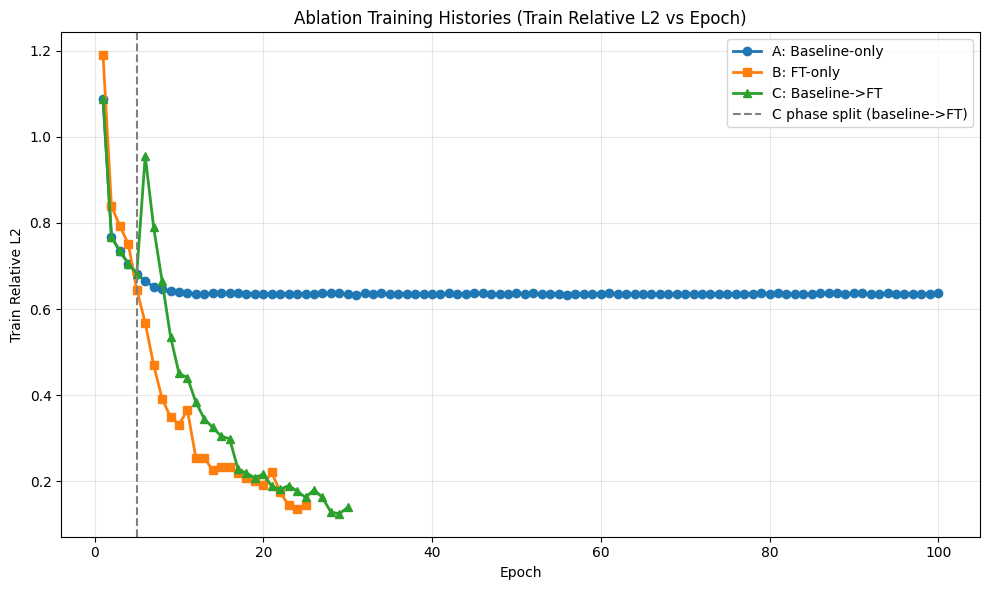

A epochs: 100, B epochs: 25, C epochs: 30
Note: B is FT-only (shorter), C includes baseline then FT phases.


In [20]:
# 16) Compare training histories for all three models (train L2 vs epoch)


def aggregate_ft_train_l2(ft_logs_obj, horizons_obj):
    # Aggregate multi-horizon FT training histories into one scalar per epoch.
    key = "train_rel_l2" if "train_rel_l2" in ft_logs_obj else "train_l2"
    if key not in ft_logs_obj:
        raise KeyError(
            "Expected fine-tune logs to contain 'train_rel_l2' (or 'train_l2')."
        )
    n_ep = len(ft_logs_obj[key][horizons_obj[0]])
    return [
        float(np.mean([ft_logs_obj[key][h][ep] for h in horizons_obj]))
        for ep in range(n_ep)
    ]


def extract_baseline_train_l2(history_obj):
    if "train_rel_l2" in history_obj:
        return history_obj["train_rel_l2"]
    if "train_l2" in history_obj:
        return history_obj["train_l2"]
    raise KeyError(
        "Expected baseline history to contain 'train_rel_l2' (or 'train_l2')."
    )


train_A = extract_baseline_train_l2(history_A)
train_B = aggregate_ft_train_l2(logs_B, horizons)
train_C_base = extract_baseline_train_l2(history_C_baseline)
train_C_ft = aggregate_ft_train_l2(logs_C_ft, horizons)
train_C = train_C_base + train_C_ft

epoch_A = np.arange(1, len(train_A) + 1)
epoch_B = np.arange(1, len(train_B) + 1)
epoch_C = np.arange(1, len(train_C) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epoch_A, train_A, marker="o", linewidth=2, label="A: Baseline-only")
ax.plot(epoch_B, train_B, marker="s", linewidth=2, label="B: FT-only")
ax.plot(epoch_C, train_C, marker="^", linewidth=2, label="C: Baseline->FT")
ax.axvline(
    x=5,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="C phase split (baseline->FT)",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train Relative L2")
ax.set_title("Ablation Training Histories (Train Relative L2 vs Epoch)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"A epochs: {len(train_A)}, B epochs: {len(train_B)}, C epochs: {len(train_C)}")
print("Note: B is FT-only (shorter), C includes baseline then FT phases.")


## 17) Track Ablation Runs in Weights & Biases


In [22]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pk222/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [24]:
import os
from getpass import getpass
import wandb

print("wandb version:", wandb.__version__)
print("WANDB_BASE_URL:", os.getenv("WANDB_BASE_URL"))
print("WANDB_ENTITY:", os.getenv("WANDB_ENTITY"))
print("WANDB_PROJECT:", os.getenv("WANDB_PROJECT"))
print("api key already set:", bool(getattr(wandb.api, "api_key", None)))

key = os.getenv("WANDB_API_KEY")
if not key:
    key = getpass("Paste W&B API key: ")

wandb.login(key=key, relogin=True, force=True)

api = wandb.Api()
viewer = api.viewer
print("logged in as:", viewer.username)

# Auth test against your target entity/project
test_run = wandb.init(
    entity="parv621-johns-hopkins-university",
    project="tipping-point-forecast-heat-rno",
    name="auth_test",
    job_type="auth_test",
)
test_run.finish()
print("auth test run created successfully")


wandb version: 0.24.2
WANDB_BASE_URL: None
WANDB_ENTITY: None
WANDB_PROJECT: None
api key already set: True


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/pk222/.netrc
wandb: Currently logged in as: parv621 (parv621-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


logged in as: parv621


auth test run created successfully


In [ ]:
# 17) Log ablation runs + checkpoints to Weights & Biases
import numpy as np
import wandb

WANDB_ENTITY = "parv621-johns-hopkins-university"
WANDB_PROJECT = "tipping-point-forecast-heat-rno"


def log_endpoint_summary(run_obj, endpoint_by_horizon):
    for h, vals in endpoint_by_horizon.items():
        run_obj.summary[f"endpoint/h{h}/mse"] = float(vals["mse"])
        run_obj.summary[f"endpoint/h{h}/rel_l2"] = float(vals["rel_l2"])
        run_obj.summary[f"endpoint/h{h}/N"] = int(vals["N"])


def log_baseline_history(run_obj, history_obj, prefix="baseline"):
    if history_obj is None:
        return
    train_vals = history_obj.get("train_rel_l2", [])
    test_vals = history_obj.get("test_rel_l2", [])
    n_ep = min(len(train_vals), len(test_vals))
    for ep in range(n_ep):
        run_obj.log(
            {
                f"{prefix}/train_rel_l2": float(train_vals[ep]),
                f"{prefix}/test_rel_l2": float(test_vals[ep]),
                "epoch": ep + 1,
            },
            step=ep + 1,
        )


def log_ft_history(
    run_obj, ft_logs_obj, horizons_obj, step_offset=0, prefix="finetune"
):
    if ft_logs_obj is None:
        return
    n_ep = len(ft_logs_obj["train_rel_l2"][horizons_obj[0]])
    for ep in range(n_ep):
        payload = {"epoch": step_offset + ep + 1}
        train_h = []
        test_h = []
        for h in horizons_obj:
            tr = float(ft_logs_obj["train_rel_l2"][h][ep])
            te = float(ft_logs_obj["test_rel_l2"][h][ep])
            payload[f"{prefix}/h{h}/train_rel_l2"] = tr
            payload[f"{prefix}/h{h}/test_rel_l2"] = te
            train_h.append(tr)
            test_h.append(te)
        payload[f"{prefix}/train_rel_l2_mean"] = float(np.mean(train_h))
        payload[f"{prefix}/test_rel_l2_mean"] = float(np.mean(test_h))
        run_obj.log(payload, step=step_offset + ep + 1)


def track_variant(
    variant,
    ckpt_path,
    ckpt_obj,
    endpoint_metrics,
    baseline_hist=None,
    ft_logs=None,
    step_offset=0,
):
    exp_id = ckpt_obj["experiment_id"]
    run_obj = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=exp_id,  # keep readable name
        group=f"heat_rno_state_only_seed{ablation_seed}",
        tags=["heat", "rno", "state_only", variant],
        config=ckpt_obj.get("hparams", {}),
        settings=wandb.Settings(start_method="thread"),
        reinit=True,
    )

    run_obj.summary["variant"] = variant
    run_obj.summary["experiment_id"] = exp_id
    run_obj.summary["checkpoint_path"] = ckpt_path

    log_endpoint_summary(run_obj, endpoint_metrics)
    log_baseline_history(run_obj, baseline_hist, prefix="baseline")
    log_ft_history(
        run_obj, ft_logs, horizons, step_offset=step_offset, prefix="finetune"
    )

    artifact = wandb.Artifact(
        name=f"{exp_id}-model",
        type="model",
        metadata={"variant": variant, "experiment_id": exp_id},
    )
    artifact.add_file(ckpt_path)
    run_obj.log_artifact(artifact)
    run_obj.finish()


track_variant(
    variant="baseline_only",
    ckpt_path=ckpt_A_path,
    ckpt_obj=ckpt_A,
    endpoint_metrics=results_baseline,
    baseline_hist=history_A,
    ft_logs=None,
    step_offset=0,
)

track_variant(
    variant="finetune_only",
    ckpt_path=ckpt_B_path,
    ckpt_obj=ckpt_B,
    endpoint_metrics=results_finetune_only,
    baseline_hist=None,
    ft_logs=logs_B,
    step_offset=0,
)

track_variant(
    variant="baseline_plus_finetune",
    ckpt_path=ckpt_C_path,
    ckpt_obj=ckpt_C,
    endpoint_metrics=results_baseline_plus_finetune,
    baseline_hist=history_C_baseline,
    ft_logs=logs_C_ft,
    step_offset=len(history_C_baseline["train_rel_l2"]),
)


wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


baseline/test_rel_l2,█▅▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
baseline/train_rel_l2,█▆▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
baseline/test_rel_l2,0.61686
baseline/train_rel_l2,0.63694
checkpoint_path,result_rno_state_onl...
endpoint/h1/N,760
endpoint/h1/mse,0.57922
endpoint/h1/rel_l2,0.61686
endpoint/h2/N,720
endpoint/h2/mse,1.17716


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
finetune/h1/test_rel_l2,█▇▆▅▄▃▃▂▂▂▃▂▂▁▁▂▁▂▁▂▁▁▁▁▁
finetune/h1/train_rel_l2,█▆▅▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
finetune/h2/test_rel_l2,██▇▆▄▄▃▂▃▂▃▂▂▁▂▂▁▂▂▁▁▁▁▁▁
finetune/h2/train_rel_l2,█▇▆▆▅▄▃▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁
finetune/h3/test_rel_l2,██▇▆▅▄▄▃▃▃▄▂▂▁▁▂▁▂▂▁▁▁▁▁▁
finetune/h3/train_rel_l2,█▇▇▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁
finetune/h4/test_rel_l2,█▇█▇▆▅▅▄▃▃▄▂▃▂▂▂▂▃▂▂▁▁▁▁▁
finetune/h4/train_rel_l2,█▅▅▅▄▄▃▃▃▂▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁
finetune/h5/test_rel_l2,█▇█▇▆▆▅▅▄▃▄▂▃▂▂▂▂▃▂▂▂▁▁▁▂
+3,...


baseline/test_rel_l2,█▆▄▂▁
baseline/train_rel_l2,█▂▂▁▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
finetune/h1/test_rel_l2,█▇▄▃▃▂▃▂▃▂▂▁▁▂▁▁▂▂▁▁▁▁▁▁▁
finetune/h1/train_rel_l2,█▇▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
finetune/h2/test_rel_l2,█▇▅▄▃▃▄▂▃▂▂▂▁▂▁▁▂▂▁▂▁▁▁▁▁
finetune/h2/train_rel_l2,█▇▆▄▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
finetune/h3/test_rel_l2,█▇▆▄▄▃▄▃▃▂▂▂▁▂▁▁▁▂▁▂▁▁▁▁▁
finetune/h3/train_rel_l2,██▆▅▄▄▃▃▃▃▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁
finetune/h4/test_rel_l2,█▇▆▅▄▃▅▄▃▂▃▂▁▂▁▁▁▂▁▂▁▁▁▁▁
+5,...
